# CLOTHING SIZE RECOMMENDATON SYSTEM.

## Project overview

Online shopping has transformed the fashion industry by allowing customers to purchase clothing from anywhere. However, choosing the correct clothing size remains a major challenge, often resulting in product returns and customer dissatisfaction.

This project aims to develop a machine learning model that recommends the most appropriate clothing size based on an individual's body measurements. The model is expected to support online fashion retailers in providing personalized size recommendations and improving the online shopping experience.

## Business understanding
Selecting the correct clothing size when shopping online is difficult because customers cannot physically try on garments before purchasing. This often leads to incorrect size selection, increased return rates, and lower customer satisfaction.

The stakeholders for this project include:

- **Online Fashion Retailers** – Improve size recommendation systems and reduce product returns.
- **Customers** – Receive personalized clothing size recommendations for better fitting garments.
- **Business Managers** – Improve customer satisfaction while reducing operational costs associated with returns

## Objectives

### Main Objective

Develop a machine learning model that recommends appropriate clothing sizes based on body measurements.

### Specific Objectives
- Explore and understand the anthropometric dataset.
- Perform data cleaning and preprocessing.
- Conduct exploratory data analysis.
- Build and compare multiple classification models.
- Deploy the best-performing model using Streamlit.

# Variables

The ANSUR II dataset contains over 100 anthropometric measurements. For this project, only the variables that are most relevant to clothing size recommendation will be used.

- **Gender** – Participant's sex (Male/Female). This feature will be created when combining the datasets.
- **Stature** – Height of the participant.
- **Weightkg** – Weight of the participant in kilograms.
- **ChestCircumference** – Chest measurement.
- **WaistCircumference** – Waist measurement.
- **HipBreadth** – Hip width measurement.
- **ShoulderBreadth** – Shoulder width measurement.
- **InseamLength** – Measurement from the crotch to the ankle.
- **Clothing Size** – Target variable to be created during feature engineering.

# Dataset Understanding

This project uses the **ANSUR II Anthropometric Dataset**, which contains detailed body measurements collected from male and female participants. The dataset includes over 100 anthropometric measurements such as height, weight, chest circumference, waist circumference, and other body dimensions that are useful for clothing size recommendation.

The dataset is provided in two separate files:
- **ANSUR II MALE Public.csv**
- **ANSUR II FEMALE Public.csv**

These datasets will be merged to create a single dataset for analysis and model development.

**Dataset Source:**
https://www.kaggle.com/datasets/seshadrikolluri/ansur-ii

## Import libraries

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the datasets

male = pd.read_csv("ANSUR II MALE Public.csv", encoding="latin1")
female = pd.read_csv("ANSUR II FEMALE Public.csv", encoding="latin1")

In [3]:
# Display the first five rows of each dataset

male.head()

,subjectid,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10027,266,1467,337,222,1347,253,202,401,369,...,Combat Arms,19D,North Dakota,1,NaN,1,41,71,180,Right hand
1,10032,233,1395,326,220,1293,245,193,394,338,...,Combat Support,68W,New York,1,NaN,1,35,68,160,Left hand
2,10033,287,1430,341,230,1327,256,196,427,408,...,Combat Support,68W,New York,2,NaN,2,42,68,205,Left hand
3,10092,234,1347,310,230,1239,262,199,401,359,...,Combat Service Support,88M,Wisconsin,1,NaN,1,31,66,175,Right hand
4,10093,250,1585,372,247,1478,267,224,435,356,...,Combat Service Support,92G,North Carolina,2,NaN,2,21,77,213,Right hand


In [4]:
female.head()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,Branch,PrimaryMOS,SubjectsBirthLocation,SubjectNumericRace,Ethnicity,DODRace,Age,Heightin,Weightlbs,WritingPreference
0,10037,231,1282,301,204,1180,222,177,373,315,...,Combat Support,92Y,Germany,2,NaN,2,26,61,142,Right hand
1,10038,194,1379,320,207,1292,225,178,372,272,...,Combat Service Support,25U,California,3,Mexican,3,21,64,120,Right hand
2,10042,183,1369,329,233,1271,237,196,397,300,...,Combat Service Support,35D,Texas,1,NaN,1,23,68,147,Right hand
3,10043,261,1356,306,214,1250,240,188,384,364,...,Combat Service Support,25U,District of Columbia,8,Caribbean Islander,2,22,66,175,Right hand
4,10051,309,1303,308,214,1210,217,182,378,320,...,Combat Arms,42A,Texas,1,NaN,1,45,63,195,Right hand


In [5]:
# Check the number of rows and columns
male.shape

(4082, 108)

In [6]:
female.shape

(1986, 108)

In [7]:
# Display dataset information
male.info()
female.info()

<class 'pandas.DataFrame'>
RangeIndex: 4082 entries, 0 to 4081
Columns: 108 entries, subjectid to WritingPreference
dtypes: int64(99), str(9)
memory usage: 3.4 MB
<class 'pandas.DataFrame'>
RangeIndex: 1986 entries, 0 to 1985
Columns: 108 entries, SubjectId to WritingPreference
dtypes: int64(99), str(9)
memory usage: 1.6 MB


In [8]:
# Summary statistics
male.describe()
female.describe()

,SubjectId,abdominalextensiondepthsitting,acromialheight,acromionradialelength,anklecircumference,axillaheight,balloffootcircumference,balloffootlength,biacromialbreadth,bicepscircumferenceflexed,...,waistfrontlengthsitting,waistheightomphalion,weightkg,wristcircumference,wristheight,SubjectNumericRace,DODRace,Age,Heightin,Weightlbs
count,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.00000,1986.000000,1986.000000,...,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000,1986.000000
mean,22306.606244,229.651057,1335.095166,311.198389,215.739678,1239.029708,228.110272,182.05136,365.348943,305.578550,...,355.136455,980.149043,677.582075,154.792548,794.190332,35.072004,1.781470,28.943605,64.601712,147.505035
std,20904.730297,31.464691,58.079885,17.164691,14.891757,55.801958,11.771007,9.64192,18.298851,30.757033,...,23.945046,50.022715,109.846458,7.827695,38.194755,955.582848,0.999536,8.332078,2.801938,22.855371
min,10037.000000,155.000000,1115.000000,249.000000,170.000000,1038.000000,194.000000,151.00000,283.000000,216.000000,...,289.000000,805.000000,358.000000,124.000000,672.000000,1.000000,1.000000,17.000000,56.000000,86.000000
25%,17667.000000,207.000000,1298.000000,300.000000,205.000000,1202.000000,220.000000,175.00000,353.000000,285.000000,...,338.000000,947.000000,601.000000,150.000000,769.000000,1.000000,1.000000,22.000000,63.000000,130.000000
50%,22096.500000,227.000000,1332.000000,311.000000,215.000000,1236.000000,227.000000,182.00000,365.000000,304.000000,...,355.000000,977.500000,668.000000,154.000000,794.000000,2.000000,2.000000,27.000000,64.000000,145.000000
75%,26089.750000,249.000000,1374.000000,323.000000,225.000000,1277.000000,236.000000,188.00000,378.000000,324.000000,...,370.000000,1013.000000,745.750000,160.000000,819.000000,3.000000,2.000000,34.000000,66.000000,161.000000
max,920103.000000,358.000000,1536.000000,371.000000,275.000000,1419.000000,270.000000,216.00000,422.000000,435.000000,...,432.000000,1142.000000,1196.000000,183.000000,941.000000,42351.000000,6.000000,58.000000,80.000000,270.000000


In [9]:
# Display all column names
male.columns

Index(['subjectid', 'abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed',
       ...
       'Branch', 'PrimaryMOS', 'SubjectsBirthLocation', 'SubjectNumericRace',
       'Ethnicity', 'DODRace', 'Age', 'Heightin', 'Weightlbs',
       'WritingPreference'],
      dtype='str', length=108)

# DATA CLEANING

In [10]:
# Check for missing values in the male dataset
male.isnull().sum()

subjectid                         0
abdominalextensiondepthsitting    0
acromialheight                    0
acromionradialelength             0
anklecircumference                0
                                 ..
DODRace                           0
Age                               0
Heightin                          0
Weightlbs                         0
WritingPreference                 0
Length: 108, dtype: int64

In [11]:
# Check for missing values in the female dataset
female.isnull().sum()

SubjectId                         0
abdominalextensiondepthsitting    0
acromialheight                    0
acromionradialelength             0
anklecircumference                0
                                 ..
DODRace                           0
Age                               0
Heightin                          0
Weightlbs                         0
WritingPreference                 0
Length: 108, dtype: int64

In [12]:
# Check for duplicate records in the male dataset
male.duplicated().sum()

np.int64(0)

In [13]:
# Check for duplicate records in the female dataset
female.duplicated().sum()

np.int64(0)

In [14]:
# Display data types for the male dataset
male.dtypes

subjectid                         int64
abdominalextensiondepthsitting    int64
acromialheight                    int64
acromionradialelength             int64
anklecircumference                int64
                                  ...  
DODRace                           int64
Age                               int64
Heightin                          int64
Weightlbs                         int64
WritingPreference                   str
Length: 108, dtype: object

In [15]:
# Display data types for the female dataset
female.dtypes

SubjectId                         int64
abdominalextensiondepthsitting    int64
acromialheight                    int64
acromionradialelength             int64
anklecircumference                int64
                                  ...  
DODRace                           int64
Age                               int64
Heightin                          int64
Weightlbs                         int64
WritingPreference                   str
Length: 108, dtype: object

In [16]:
# Verify the Gender values
male["Gender"].value_counts()

Gender
Male    4082
Name: count, dtype: int64

In [17]:
female["Gender"].value_counts()

Gender
Female    1986
Name: count, dtype: int64

In [18]:
# Merge the male and female datasets
df = pd.concat([male, female], ignore_index=True)

df.shape

(6068, 109)

In [19]:
# Check for missing values after merging
df.isnull().sum().sum()

np.int64(10715)

In [20]:
# Display columns with missing values only

df.isnull().sum()[df.isnull().sum() > 0]

subjectid    1986
Ethnicity    4647
SubjectId    4082
dtype: int64

In [21]:
# Remove duplicate identifier columns
df.drop(columns=["subjectid", "SubjectId"], inplace=True)

In [22]:
# Remove the Ethnicity column since it is not relevant for clothing size prediction
df.drop(columns=["Ethnicity"], inplace=True)
 

In [23]:
# Check for remaining missing values
df.isnull().sum().sum()

np.int64(0)

# Data Preprocessing

Data preprocessing involves transforming the cleaned dataset into a suitable format for analysis and machine learning. This includes selecting relevant features, removing unnecessary variables, renaming columns for better readability, creating the target variable, and preparing the data for model development.

In [24]:
# Display all column names

df.columns

Index(['abdominalextensiondepthsitting', 'acromialheight',
       'acromionradialelength', 'anklecircumference', 'axillaheight',
       'balloffootcircumference', 'balloffootlength', 'biacromialbreadth',
       'bicepscircumferenceflexed', 'bicristalbreadth',
       ...
       'Component', 'Branch', 'PrimaryMOS', 'SubjectsBirthLocation',
       'SubjectNumericRace', 'DODRace', 'Age', 'Heightin', 'Weightlbs',
       'WritingPreference'],
      dtype='str', length=106)

In [25]:

# Select features for the clothing size recommendation system

selected_columns = [
    "Gender",
    "stature",
    "weightkg",
    "chestcircumference",
    "waistcircumference",
    "hipbreadth",
    "neckcircumference",
    "shouldercircumference",
    "sleevelengthspinewrist",
    "thighcircumference",
    "calfcircumference",
    "functionalleglength"
]

df = df[selected_columns]

In [26]:

# Rename columns for better readability

df.rename(columns={
    "Gender": "gender",
    "stature": "height_mm",
    "weightkg": "weight_kg",
    "chestcircumference": "chest_circumference_mm",
    "waistcircumference": "waist_circumference_mm",
    "hipbreadth": "hip_breadth_mm",
    "neckcircumference": "neck_circumference_mm",
    "shouldercircumference": "shoulder_circumference_mm",
    "sleevelengthspinewrist": "arm_length_mm",
    "thighcircumference": "thigh_circumference_mm",
    "calfcircumference": "calf_circumference_mm" ,
    "functionalleglength": "leg_length_mm"
}, inplace=True)

df.head()


,gender,height_mm,weight_kg,chest_circumference_mm,waist_circumference_mm,hip_breadth_mm,neck_circumference_mm,shoulder_circumference_mm,arm_length_mm,thigh_circumference_mm,calf_circumference_mm,leg_length_mm
0,Male,1776,815,1074,933,332,400,1151,883,610,373,1136
1,Male,1702,726,1021,870,312,380,1119,868,572,357,1096
2,Male,1735,929,1120,964,349,403,1276,910,685,412,1115
3,Male,1655,794,1114,857,338,407,1155,848,604,395,1034
4,Male,1914,946,1048,868,332,398,1231,995,672,425,1279


In [27]:
# Check the final dataset dimensions
df.shape

(6068, 12)

# EXPLORATORY DATA ANALYSIS (EDA)

## Gender Distribution

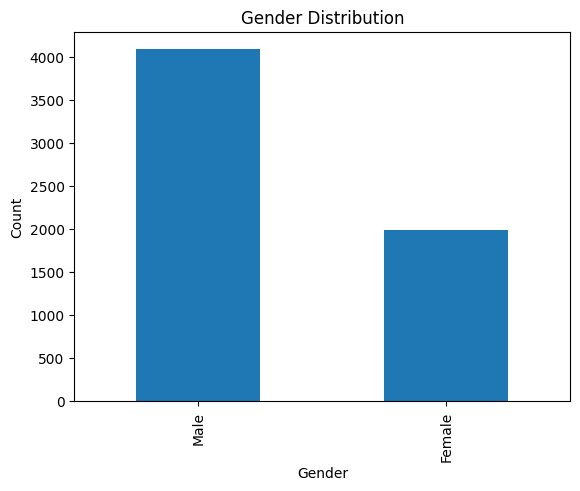

In [28]:

# Visualize gender distribution


df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both male and female participants.
- Male participants are more numerous than female participants.

# Height distribution

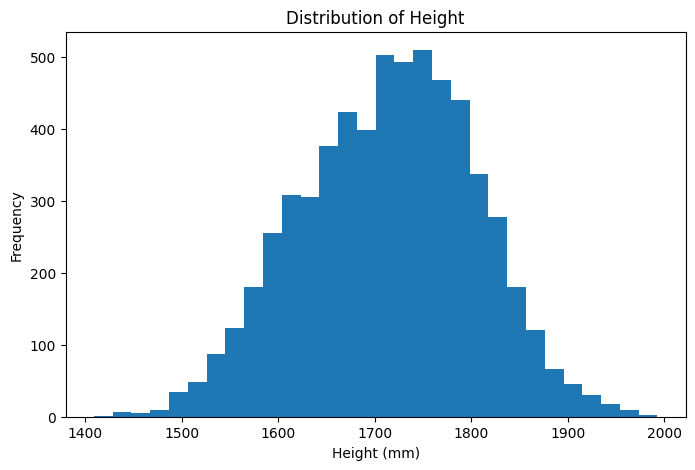

In [29]:
# Distribution of height

plt.figure(figsize=(8,5))

plt.hist(df["height_mm"], bins=30)

plt.title("Distribution of Height")
plt.xlabel("Height (mm)")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most participants have heights between approximately **1600 mm and 1800 mm**.
- The frequency of participants decreases towards both the shorter and taller height ranges.

# Height vs weight

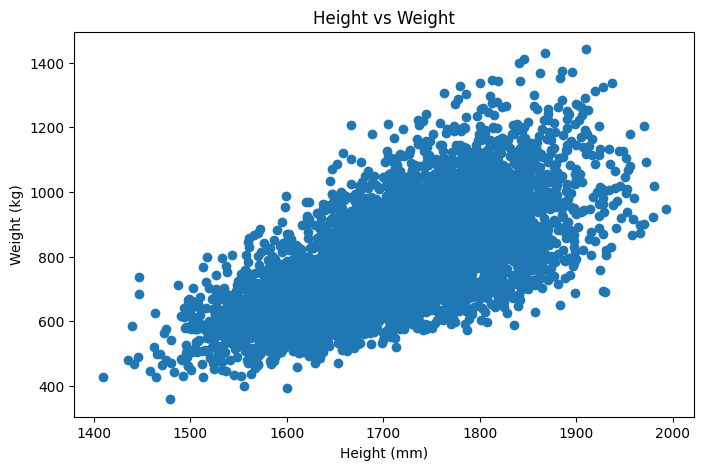

In [30]:
# Relationship between height and weight

plt.figure(figsize=(8,5))

plt.scatter(df["height_mm"], df["weight_kg"])

plt.title("Height vs Weight")
plt.xlabel("Height (mm)")
plt.ylabel("Weight (kg)")

plt.show()

### Observation

- There is a positive relationship between height and weight, where taller participants generally tend to have higher body weights.
- Most participants are concentrated around the middle ranges of both height and weight.

# Hip breadth vs gender

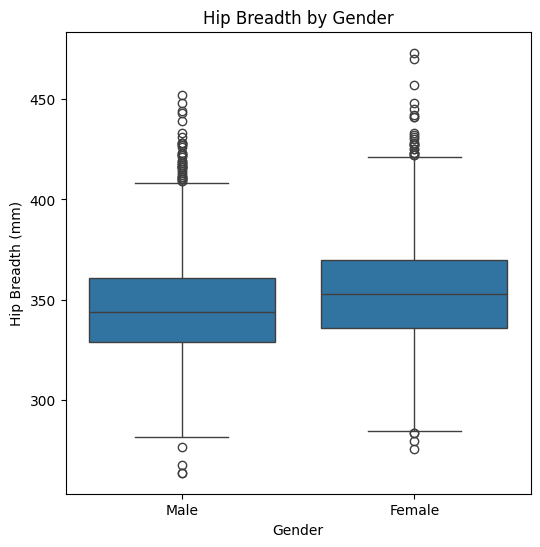

In [31]:
# Hip breadth by gender

plt.figure(figsize=(6,6))

sns.boxplot(x="gender", y="hip_breadth_mm", data=df)

plt.title("Hip Breadth by Gender")
plt.xlabel("Gender")
plt.ylabel("Hip Breadth (mm)")

plt.show()

### Observation

- Female participants generally have higher hip breadth measurements than male participants.
- Outliers are present in both gender groups.

# Correlation heatmap

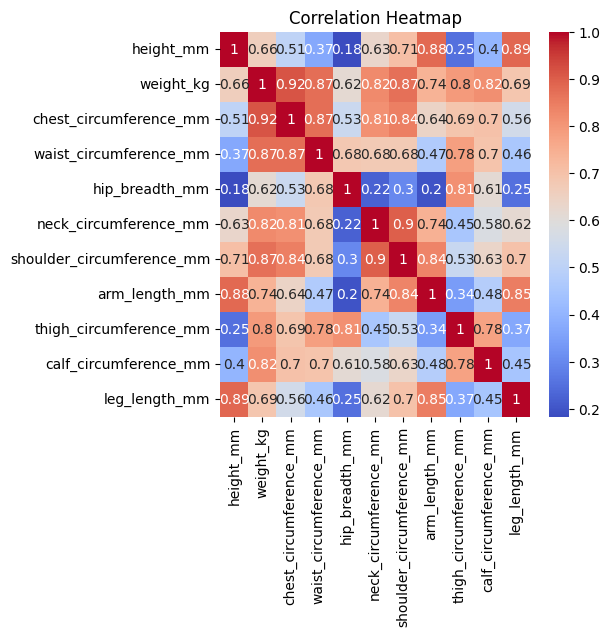

In [32]:
# Correlation heatmap

plt.figure(figsize=(5,5))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Most body measurements are positively correlated, indicating that larger body dimensions tend to occur together.
- Neck circumference and shoulder circumference have a strong positive correlation (0.90), showing a close relationship between these upper-body measurements.


# Feature Engineering

## Creating the Target Variable

The ANSUR II dataset does not contain predefined clothing size labels. Therefore, created a target variable using internationally recognised clothing sizing standards.



In [33]:
# Convert measurements from millimetres to centimetres
# International clothing size charts commonly use centimetres.

df["chest_cm"] = df["chest_circumference_mm"] / 10
df["waist_cm"] = df["waist_circumference_mm"] / 10
df["hip_cm"] = df["hip_breadth_mm"] / 10

In [34]:
# Define clothing sizes from smallest to largest

size_order = {
    "XS": 0,
    "S": 1,
    "M": 2,
    "L": 3,
    "XL": 4,
    "XXL": 5,
    "XXXL": 6
}

### Male Clothing Size Functions

In [35]:
# chest circumference
def male_chest_size(chest):

    if chest < 86:
        return "XS"
    elif chest < 94:
        return "S"
    elif chest < 102:
        return "M"
    elif chest < 110:
        return "L"
    elif chest < 118:
        return "XL"
    elif chest < 126:
        return "XXL"
    else:
        return "XXXL"

In [36]:
# waist circumference
def male_waist_size(waist):

    if waist < 72:
        return "XS"
    elif waist < 80:
        return "S"
    elif waist < 88:
        return "M"
    elif waist < 96:
        return "L"
    elif waist < 104:
        return "XL"
    elif waist < 112:
        return "XXL"
    else:
        return "XXXL"

In [37]:
# hip breadth
def male_hip_size(hip):

    if hip < 31:
        return "XS"
    elif hip < 34:
        return "S"
    elif hip < 37:
        return "M"
    elif hip < 40:
        return "L"
    elif hip < 43:
        return "XL"
    elif hip < 46:
        return "XXL"
    else:
        return "XXXL"

### Female clothing size functions

In [38]:
# chest circumference
def female_chest_size(chest):

    if chest < 80:
        return "XS"
    elif chest < 88:
        return "S"
    elif chest < 96:
        return "M"
    elif chest < 104:
        return "L"
    elif chest < 112:
        return "XL"
    elif chest < 120:
        return "XXL"
    else:
        return "XXXL"

In [39]:
# waist circumference
def female_waist_size(waist):

    if waist < 64:
        return "XS"
    elif waist < 72:
        return "S"
    elif waist < 80:
        return "M"
    elif waist < 88:
        return "L"
    elif waist < 96:
        return "XL"
    elif waist < 104:
        return "XXL"
    else:
        return "XXXL"


In [40]:
#hip breadth
def female_hip_size(hip):

    if hip < 30:
        return "XS"
    elif hip < 33:
        return "S"
    elif hip < 36:
        return "M"
    elif hip < 39:
        return "L"
    elif hip < 42:
        return "XL"
    elif hip < 45:
        return "XXL"
    else:
        return "XXXL"

### Final clothing size

In [41]:
# Assign the final clothing size.
# If measurements fall into different size categories,
# the largest size is selected to improve overall clothing fit.

def assign_size(row):

    if row["gender"] == "Male":

        sizes = [
            male_chest_size(row["chest_cm"]),
            male_waist_size(row["waist_cm"]),
            male_hip_size(row["hip_cm"])
        ]

    else:

        sizes = [
            female_chest_size(row["chest_cm"]),
            female_waist_size(row["waist_cm"]),
            female_hip_size(row["hip_cm"])
        ]

    return max(sizes, key=lambda size: size_order[size])

In [42]:
# Create the clothing size target variable

df["clothing_size"] = df.apply(assign_size, axis=1)

In [43]:
# Display the distribution of clothing sizes

df["clothing_size"].value_counts().sort_index()

clothing_size
L       1809
M       1266
S        306
XL      1529
XS        12
XXL      788
XXXL     358
Name: count, dtype: int64

In [44]:

# Remove temporary columns used to create the target variable

df.drop(columns=["chest_cm", "waist_cm", "hip_cm"], inplace=True)


In [45]:
# Display the first five rows of the dataset

df.head()

,gender,height_mm,weight_kg,chest_circumference_mm,waist_circumference_mm,hip_breadth_mm,neck_circumference_mm,shoulder_circumference_mm,arm_length_mm,thigh_circumference_mm,calf_circumference_mm,leg_length_mm,clothing_size
0,Male,1776,815,1074,933,332,400,1151,883,610,373,1136,L
1,Male,1702,726,1021,870,312,380,1119,868,572,357,1096,L
2,Male,1735,929,1120,964,349,403,1276,910,685,412,1115,XL
3,Male,1655,794,1114,857,338,407,1155,848,604,395,1034,XL
4,Male,1914,946,1048,868,332,398,1231,995,672,425,1279,L


# Clothing size distribtion

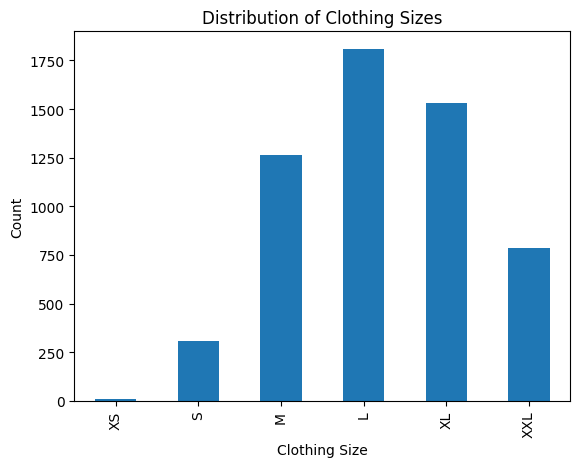

In [46]:
# Visualize the clothing size distribution

size_order = ["XS", "S", "M", "L", "XL", "XXL"]

df["clothing_size"].value_counts().reindex(size_order).plot(kind="bar")

plt.title("Distribution of Clothing Sizes")
plt.xlabel("Clothing Size")
plt.ylabel("Count")

plt.show()

### Observation

- Medium (M) and Large (L) are the most common clothing sizes in the dataset.
- XS and XXL are the fewest among all clothing size categories.

In [47]:
# Save the cleaned dataset

df.to_csv("cleaned_clothing_dataset.csv", index=False)

# MACHINE LEARNING

The objective of this stage is to develop a machine learning model capable of predicting clothing sizes from anthropometric body measurements.


In [48]:
# Separate predictor variables (X) and target variable (y)

X = df.drop(columns=["clothing_size"])

y = df["clothing_size"]

In [49]:
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Encode the gender column into numerical values

label_encoder = LabelEncoder()

X["gender"] = label_encoder.fit_transform(X["gender"])

In [50]:
# Import train-test split

from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Baseline Model

A Dummy Classifier was used as the baseline model. The model predicts the most frequent clothing size and serves as a benchmark against which more advanced machine learning models are compared.

In [51]:
# Import Dummy Classifier

from sklearn.dummy import DummyClassifier

# Create the baseline model

baseline_model = DummyClassifier(strategy="most_frequent")

# Train the baseline model

baseline_model.fit(X_train, y_train)

# Predict clothing sizes

baseline_predictions = baseline_model.predict(X_test)

In [52]:
# Import evaluation metrics

from sklearn.metrics import accuracy_score

# Calculate baseline accuracy

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.2982


### Observation

The baseline model has an accuracy of **29.82%** by predicting the most frequent clothing size. This provides a benchmark against which the performance of the Decision Tree and Random Forest models will be compared.

## Evaluation Metrics


- **Accuracy:** Measures the overall proportion of correct predictions made by the model.

- **Precision:** Measures how many of the predicted clothing sizes were actually correct.

- **Recall:** Measures how many of the actual clothing sizes were correctly identified by the model.

- **F1-score:** The mean of precision and recall. It provides a balanced measure of model performance, especially when class distributions are uneven.



## Decision Tree Classifier Model

A Decision Tree classifier was trained to learn the relationship between anthropometric measurements and clothing sizes.

In [53]:
# Import Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# Create the Decision Tree model

decision_tree = DecisionTreeClassifier(
    random_state=42
)

# Train the model

decision_tree.fit(X_train, y_train)

# Predict clothing sizes

dt_predictions = decision_tree.predict(X_test)

In [54]:
# Import evaluation metrics

from sklearn.metrics import classification_report

# Display classification report

print(classification_report(
    y_test,
    dt_predictions
))

              precision    recall  f1-score   support

           L       1.00      0.99      1.00       362
           M       0.99      0.98      0.99       253
           S       0.89      0.95      0.92        61
          XL       0.99      1.00      1.00       306
          XS       0.00      0.00      0.00         2
         XXL       1.00      0.99      0.99       158
        XXXL       1.00      1.00      1.00        72

    accuracy                           0.99      1214
   macro avg       0.84      0.84      0.84      1214
weighted avg       0.99      0.99      0.99      1214



### Observation

The Decision Tree classifier achieved an **accuracy of 99%**, indicating excellent overall prediction performance.

The model achieved **high precision**, meaning most predicted clothing sizes were correct, while the **high recall** shows that it correctly identified most of the actual clothing sizes.

The **F1-score** was also high across most classes, demonstrating a good balance between precision and recall.

The only poorly performing class was **XS**, which contained only **2 test samples**, limiting the model's ability to accurately classify this category.

## Random Forest Classifier Model

A Random Forest classifier was trained to improve prediction accuracy by combining multiple decision trees.

In [55]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model

random_forest.fit(X_train, y_train)

# Predict clothing sizes

rf_predictions = random_forest.predict(X_test)

In [56]:
# Display classification report

print(classification_report(
    y_test,
    rf_predictions,
    zero_division=0
))

              precision    recall  f1-score   support

           L       0.99      0.99      0.99       362
           M       0.98      1.00      0.99       253
           S       0.97      0.95      0.96        61
          XL       0.99      0.99      0.99       306
          XS       0.00      0.00      0.00         2
         XXL       0.97      0.98      0.98       158
        XXXL       1.00      0.96      0.98        72

    accuracy                           0.99      1214
   macro avg       0.84      0.84      0.84      1214
weighted avg       0.99      0.99      0.99      1214



### Observation

The Random Forest classifier achieved an overall **accuracy of 99%**, indicating excellent performance in predicting clothing sizes.

The model achieved **high precision**, meaning that most of the predicted clothing sizes were correct. It also achieved **high recall**, indicating that it correctly identified the majority of the actual clothing size categories.

The **F1-score** was also high for most clothing size classes, demonstrating a good balance between precision and recall and confirming the model's strong overall performance.



## Compare the models


In [57]:
# Calculate model accuracies

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

# Display model accuracies

print(f"Baseline Accuracy      : {baseline_accuracy:.4f}")

print(f"Decision Tree Accuracy : {dt_accuracy:.4f}")

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Baseline Accuracy      : 0.2982
Decision Tree Accuracy : 0.9885
Random Forest Accuracy : 0.9868


### select the best model


In [58]:
# Select the model with the highest accuracy

if rf_accuracy > dt_accuracy:
    best_model = random_forest
    print("Random Forest selected as the final model.")

else:
    best_model = decision_tree
    print("Decision Tree selected as the final model.")

Decision Tree selected as the final model.


## save the model

In [59]:
import joblib

joblib.dump(decision_tree, "clothing_size_model.pkl")

['clothing_size_model.pkl']

# Final Insights


- The Decision Tree classifier achieved the highest accuracy (**98.85%**), making it the most suitable model for the clothing size recommendation system.

- Body measurements such as chest circumference, waist circumference and hip breadth were the most influential features in determining clothing size.

- The limited number of **XS** observations affected the model's performance for that clothing size, highlighting the importance of balanced datasets.

- The developed model provides a strong foundation for a practical clothing size recommendation system and can be further enhanced with features such as automatic unit conversion, measurement guides and computer vision in future versions.


# Recommendations

- The developed clothing size recommendation system should be adopted to improve the accuracy of clothing size selection.

- The model should be periodically updated using new anthropometric data to maintain its effectiveness.

- Future enhancements may include computer vision techniques to automatically estimate body measurements from user images.